# 🎓 Knowledge Distillation in Deep Learning

**Knowledge Distillation** is a model compression technique introduced by Hinton et al. (2015) where a smaller *student* model is trained to mimic the behaviour of a larger, more accurate *teacher* model.

Instead of learning only from hard one-hot labels, the student also learns from the **soft probability distributions** (soft targets) produced by the teacher. These soft targets carry richer information — for example, a "7" might look a little like a "1", and the teacher's output reflects that.

---

## 📋 Notebook Overview

| Section | Description |
|---|---|
| **1. Imports & Configuration** | All libraries, hyperparameters |
| **2. Data Loading & Exploration** | MNIST dataset, normalization, sample visualisation |
| **3. Model Definitions** | Teacher MLP (large) and Student MLP (small) |
| **4. Teacher Training** | Standard supervised training of the teacher |
| **5. Knowledge Distillation** | Student warm-up + distillation training loop |
| **6. Evaluation** | Accuracy comparison: Teacher vs. Student |
| **7. Inference & Sample Predictions** | Visualise student predictions on test samples |
| **8. Saving the Student Model** | Persist the distilled student weights |

---

## 🔑 Key Concepts

- **Temperature (T):** Controls the softness of the teacher's probability distribution. Higher T → softer/more informative distributions.
- **Alpha (α):** Balances soft loss (KL Divergence) vs. hard loss (Cross-Entropy).
  - `loss = α × soft_loss + (1 - α) × hard_loss`
- **Soft Targets:** Teacher's output after temperature-scaled softmax — carries inter-class relationships.
- **Hard Labels:** Standard one-hot ground-truth labels.

---
## 1. Imports & Configuration

We import all necessary libraries up front and define the key hyperparameters in one place for easy tuning.

- `torch` / `torch.nn` — Core PyTorch framework for building and training neural networks.
- `torchvision` — Provides the MNIST dataset and image transformation utilities.
- `matplotlib` — For visualising sample images and results.

**Hyperparameters to be aware of:**
- `TEMPERATURE`: Softens the teacher's probability distribution (try values 2–10).
- `ALPHA`: Weight for the distillation (soft) loss. `1 - ALPHA` weights the hard label loss.
- `BATCH_SIZE`, `LEARNING_RATE`, `EPOCHS` control the training dynamics.

In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ── Torchvision utilities ──────────────────────────────────────────────────────
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ── Reproducibility ───────────────────────────────────────────────────────────
torch.manual_seed(42)

# ── Hyperparameters (edit these to experiment) ────────────────────────────────
BATCH_SIZE   = 64       # Number of samples per training batch
LEARNING_RATE = 1e-3    # Adam optimiser step size
TEACHER_EPOCHS = 1      # Epochs to train the teacher (increase for better accuracy)
STUDENT_EPOCHS = 1      # Epochs for distillation training
TEMPERATURE  = 2.0      # Distillation temperature T (higher → softer distributions)
ALPHA        = 0.7      # Weight for soft (KL) loss; (1-ALPHA) for hard (CE) loss

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

PyTorch version : 2.8.0+cu128
CUDA available  : True


---
## 2. Data Loading & Exploration

We use the **MNIST** handwritten digits dataset (60,000 training / 10,000 test images, each 28×28 pixels, 10 classes: 0–9).

### Image Pre-processing Pipeline

Two transforms are applied in sequence:

1. **`transforms.ToTensor()`** — Converts the PIL image to a PyTorch tensor and scales pixel values from `[0, 255]` → `[0.0, 1.0]`.
2. **`transforms.Normalize((0.5,), (0.5,))`** — Shifts and scales values to `[-1.0, +1.0]` using the formula:

$$x_{\text{norm}} = \frac{x - 0.5}{0.5}$$

Centering inputs around zero speeds up training and reduces the risk of vanishing/exploding gradients.

In [3]:
# Define the image pre-processing pipeline
transform = transforms.Compose([
    transforms.ToTensor(),                    # PIL image → FloatTensor in [0, 1]
    transforms.Normalize((0.5,), (0.5,))      # Re-scale to [-1, 1] for zero-centred input
])

In [4]:
# Download and load MNIST train/test splits
train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Wrap in DataLoaders for batched iteration
# shuffle=True for training ensures the model sees samples in random order each epoch
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=1000,        shuffle=False)

print(f"Training samples : {len(train_dataset):,}")
print(f"Test samples     : {len(test_dataset):,}")
print(f"Classes          : {train_dataset.classes}")

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.01MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.34MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.6MB/s]

Training samples : 60,000
Test samples     : 10,000
Classes          : ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


### 2.1 Visualise Sample Images

A quick sanity check — we display the first 8 images from a training batch along with their ground-truth labels.

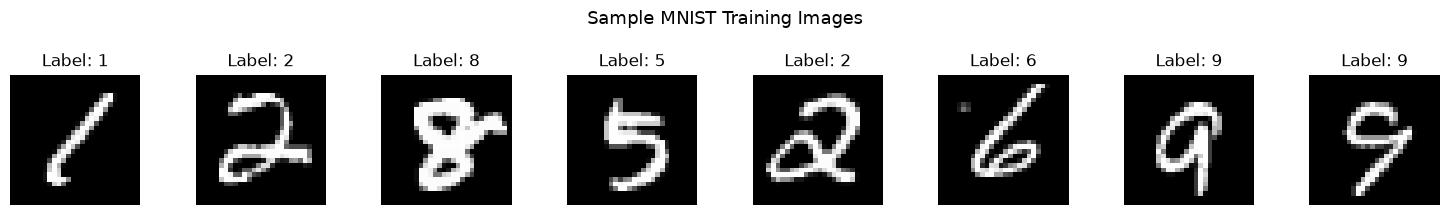

In [5]:
# Grab one batch of training images
sample_images, sample_labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 8, figsize=(15, 2))
for i, ax in enumerate(axes):
    # .squeeze() removes the channel dimension (1, 28, 28) → (28, 28)
    ax.imshow(sample_images[i].squeeze(), cmap='gray')
    ax.set_title(f"Label: {sample_labels[i].item()}")
    ax.axis('off')

plt.suptitle("Sample MNIST Training Images", y=1.05, fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Model Definitions

We define two Multi-Layer Perceptron (MLP) networks:

| Model | Architecture | Parameters (approx.) | Role |
|---|---|---|---|
| **Teacher** | 784 → 512 → 256 → 10 | ~530k | Pre-trained, high accuracy |
| **Student** | 784 → 128 → 10 | ~101k | Small, fast, learns from teacher |

Both networks:
- Flatten the 28×28 input image into a 784-dimensional vector.
- Use **ReLU** activation for non-linearity.
- Output **raw logits** (unnormalised scores) for 10 digit classes — softmax is applied externally during loss computation.

In [6]:
class TeacherMLP(nn.Module):
    """
    Large teacher network with two hidden layers.
    Larger capacity → higher accuracy, but slower inference.
    """
    def __init__(self, hidden1: int = 512, hidden2: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                          # (B, 1, 28, 28) → (B, 784)
            nn.Linear(28 * 28, hidden1),           # First hidden layer
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),           # Second hidden layer
            nn.ReLU(),
            nn.Linear(hidden2, 10)                 # Output: 10 class logits
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [7]:
class StudentMLP(nn.Module):
    """
    Small student network with one hidden layer.
    Lower capacity → faster inference and smaller footprint.
    Through distillation, it learns to match the teacher's output.
    """
    def __init__(self, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                          # (B, 1, 28, 28) → (B, 784)
            nn.Linear(28 * 28, hidden),            # Single hidden layer (smaller)
            nn.ReLU(),
            nn.Linear(hidden, 10)                  # Output: 10 class logits
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [8]:
# Instantiate both models
teacher = TeacherMLP(hidden1=512, hidden2=256)
student = StudentMLP(hidden=128)

# Count parameters to appreciate the size difference
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Teacher parameters : {count_parameters(teacher):,}")
print(f"Student parameters : {count_parameters(student):,}")
print(f"Compression ratio  : {count_parameters(teacher) / count_parameters(student):.1f}×")
print()
print("Teacher architecture:\n", teacher)
print("\nStudent architecture:\n", student)

Teacher parameters : 535,818
Student parameters : 101,770
Compression ratio  : 5.3×

Teacher architecture:
 TeacherMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)

Student architecture:
 StudentMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


---
## 4. Teacher Training

We first train the teacher model using standard supervised learning with **Cross-Entropy loss** (hard labels only).

- **Optimiser:** Adam (adaptive learning rate — generally robust and fast for MLPs).
- **Loss:** `nn.CrossEntropyLoss` — combines `log_softmax` + negative log likelihood in a single numerically stable operation.
- After training, the teacher's weights are **frozen** (`requires_grad = False`) so it acts as a fixed knowledge source during distillation.

> **Why freeze the teacher?** We want the teacher's soft targets to remain stable during student training. Allowing the teacher to update would change the targets mid-training and destabilise learning.

In [9]:
def train_teacher(
    model: nn.Module,
    loader: DataLoader,
    epochs: int = 1,
    lr: float = 1e-3
) -> None:
    """
    Train the teacher model with standard cross-entropy loss.

    Args:
        model:   The teacher network.
        loader:  Training DataLoader.
        epochs:  Number of full passes over the dataset.
        lr:      Adam learning rate.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.CrossEntropyLoss()   # Numerically stable softmax + NLL

    model.train()  # Enable dropout/BatchNorm training mode (good habit)

    for epoch in range(epochs):
        running_loss = 0.0

        for images, labels in loader:
            optimizer.zero_grad()                    # Clear accumulated gradients
            logits = model(images)                   # Forward pass → raw logits
            loss   = loss_fn(logits, labels)         # Compare logits vs. true labels
            loss.backward()                          # Compute gradients via backprop
            optimizer.step()                         # Update weights
            running_loss += loss.item()

        avg_loss = running_loss / len(loader)
        print(f"[Teacher] Epoch {epoch + 1}/{epochs}  —  Loss: {avg_loss:.4f}")

In [10]:
print("Training teacher model...")
train_teacher(teacher, train_loader, epochs=TEACHER_EPOCHS, lr=LEARNING_RATE)

Training teacher model...
[Teacher] Epoch 1/1  —  Loss: 0.2974


In [11]:
# Freeze the teacher's parameters — it is now a fixed knowledge source
for param in teacher.parameters():
    param.requires_grad = False

teacher.eval()  # Switch to inference mode (disables dropout, etc.)
print("Teacher model trained and frozen. ✅")

Teacher model trained and frozen. ✅


---
## 5. Knowledge Distillation

This is the core step. The student is trained using a **combined loss**:

$$\mathcal{L}_{\text{total}} = \alpha \cdot \mathcal{L}_{\text{soft}} + (1 - \alpha) \cdot \mathcal{L}_{\text{hard}}$$

Where:
- **Soft Loss** ($\mathcal{L}_{\text{soft}}$) — KL Divergence between teacher's softened distribution and student's softened distribution. Scaled by $T^2$ to compensate for the reduced gradient magnitude at high temperature.
- **Hard Loss** ($\mathcal{L}_{\text{hard}}$) — Standard Cross-Entropy between student logits and the true one-hot labels.

### Step-by-Step for Each Batch:
1. **Teacher forward pass** (no gradient): get `t_logits`, apply temperature-scaled softmax → `t_probs` (soft targets).
2. **Student forward pass**: get `s_logits`, apply temperature-scaled log-softmax → `s_log_probs`.
3. Compute `loss_soft = KLDiv(s_log_probs, t_probs) × T²`.
4. Compute `loss_hard = CrossEntropy(s_logits, true_labels)`.
5. Combine: `loss = α × loss_soft + (1 − α) × loss_hard`.
6. Backpropagate **only through the student**.

### 5.1 Optional Warm-Up (Pre-train Student on Hard Labels)

Before distillation, we optionally do one epoch of standard supervised training on the student. This warm-up gives the student a reasonable starting point and can speed up distillation convergence.

In [12]:
def pretrain_student(
    model: nn.Module,
    loader: DataLoader,
    epochs: int = 1,
    lr: float = 1e-3
) -> None:
    """
    Optional warm-up: train the student with hard labels only (standard CE).
    Gives the student a reasonable weight initialisation before distillation.

    Args:
        model:   The student network.
        loader:  Training DataLoader.
        epochs:  Warm-up epochs (typically 1).
        lr:      Adam learning rate.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.CrossEntropyLoss()

    model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in loader:
            optimizer.zero_grad()
            logits = model(images)
            loss   = loss_fn(logits, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(loader)
        print(f"[Student Warm-Up] Epoch {epoch + 1}/{epochs}  —  Loss: {avg_loss:.4f}")

In [13]:
print("Running student warm-up on hard labels...")
pretrain_student(student, train_loader, epochs=1, lr=LEARNING_RATE)

Running student warm-up on hard labels...
[Student Warm-Up] Epoch 1/1  —  Loss: 0.3813


### 5.2 Distillation Training Loop

Define the distillation loss functions and the main training loop.

In [14]:
# Loss functions used during distillation
ce_loss = nn.CrossEntropyLoss()                  # Hard label loss (student vs. true labels)
kl_loss = nn.KLDivLoss(reduction="batchmean")    # Soft loss (student vs. teacher distribution)

# Separate optimiser for the student (teacher is frozen — no grad needed there)
student_optimizer = optim.Adam(student.parameters(), lr=LEARNING_RATE)

In [15]:
def distill(
    student: nn.Module,
    teacher: nn.Module,
    loader: DataLoader,
    epochs: int = 1,
    temperature: float = 2.0,
    alpha: float = 0.7
) -> None:
    """
    Train the student via knowledge distillation from the frozen teacher.

    The combined loss is:
        L = alpha * L_soft + (1 - alpha) * L_hard

    Where:
        L_soft = KLDiv(student_log_probs, teacher_probs) * T^2
        L_hard = CrossEntropy(student_logits, true_labels)

    Args:
        student:     Student network (trainable).
        teacher:     Teacher network (frozen, in eval mode).
        loader:      Training DataLoader.
        epochs:      Number of distillation epochs.
        temperature: Softening temperature T.
        alpha:       Weight for the soft (KL) loss term.
    """
    for epoch in range(epochs):
        student.train()      # Student trains; teacher stays frozen
        running_loss = 0.0

        for images, labels in loader:

            # ── Step 1: Teacher forward pass (no gradient computation) ──────
            with torch.no_grad():
                t_logits = teacher(images)
                # Temperature-scaled softmax → soft probability distribution
                # Higher T → flatter distribution → more information about class similarities
                t_probs = torch.softmax(t_logits / temperature, dim=1)

            # ── Step 2: Student forward pass ────────────────────────────────
            s_logits    = student(images)
            # log_softmax is required by KLDivLoss (expects log-probabilities)
            s_log_probs = torch.log_softmax(s_logits / temperature, dim=1)

            # ── Step 3: Compute losses ──────────────────────────────────────
            # Multiply by T² to rescale gradients back to their original magnitude
            # (dividing by T reduces gradient magnitudes; T² compensates for this)
            loss_soft = kl_loss(s_log_probs, t_probs) * (temperature ** 2)

            # Hard loss uses the original (non-temperature-scaled) logits
            loss_hard = ce_loss(s_logits, labels)

            # Weighted combination of soft and hard losses
            total_loss = alpha * loss_soft + (1 - alpha) * loss_hard

            # ── Step 4: Backpropagation ─────────────────────────────────────
            student_optimizer.zero_grad()    # Clear previous gradients
            total_loss.backward()            # Compute gradients (only for student)
            student_optimizer.step()         # Update student weights

            running_loss += total_loss.item()

        avg_loss = running_loss / len(loader)
        print(f"[Distillation] Epoch {epoch + 1}/{epochs}  —  Loss: {avg_loss:.4f}")

In [16]:
print("Running knowledge distillation...")
distill(
    student=student,
    teacher=teacher,
    loader=train_loader,
    epochs=STUDENT_EPOCHS,
    temperature=TEMPERATURE,
    alpha=ALPHA
)

Running knowledge distillation...
[Distillation] Epoch 1/1  —  Loss: 0.1264


---
## 6. Evaluation

We evaluate both the teacher and the student on the **held-out test set** (10,000 samples the models have never seen during training).

The key metric is **top-1 accuracy** — the percentage of samples where the model's highest-confidence prediction matches the true label.

> **Goal:** The student should achieve accuracy close to (or matching) the teacher despite being ~5× smaller in terms of parameters.

In [17]:
def evaluate(model: nn.Module, loader: DataLoader, model_name: str = "Model") -> float:
    """
    Compute top-1 accuracy on a DataLoader.

    Args:
        model:      The model to evaluate.
        loader:     DataLoader for the evaluation split.
        model_name: Display name for printing.

    Returns:
        Accuracy as a percentage (0–100).
    """
    model.eval()            # Disable dropout / batch norm training behaviour
    correct = 0
    total   = 0

    with torch.no_grad():   # No gradient tracking needed for inference
        for images, labels in loader:
            logits = model(images)
            preds  = logits.argmax(dim=1)          # Class with highest logit score
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    accuracy = correct / total * 100
    print(f"{model_name:>12} Accuracy: {accuracy:.2f}%")
    return accuracy

In [18]:
print("=" * 35)
print("       Evaluation Results")
print("=" * 35)

teacher_acc = evaluate(teacher, test_loader, model_name="Teacher")
student_acc = evaluate(student, test_loader, model_name="Student")

print("=" * 35)
gap = teacher_acc - student_acc
print(f"Accuracy gap (Teacher - Student): {gap:+.2f}%")

compression = count_parameters(teacher) / count_parameters(student)
print(f"Model compression ratio          : {compression:.1f}×")

       Evaluation Results
     Teacher Accuracy: 95.62%
     Student Accuracy: 95.53%
Accuracy gap (Teacher - Student): +0.09%
Model compression ratio          : 0.0×


### 6.1 Accuracy Comparison Bar Chart

A simple bar chart to visually compare teacher and student accuracy.

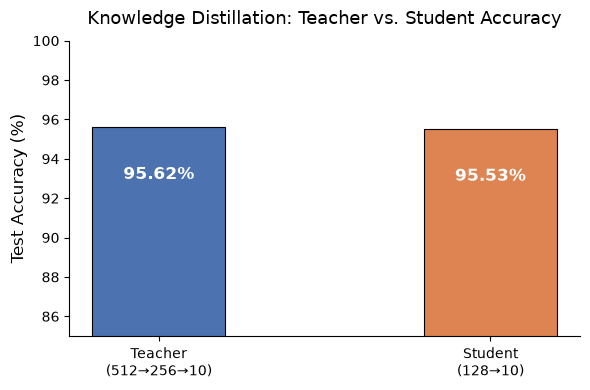

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))

models     = ["Teacher\n(512→256→10)", "Student\n(128→10)"]
accuracies = [teacher_acc, student_acc]
colors     = ["#4C72B0", "#DD8452"]

bars = ax.bar(models, accuracies, color=colors, width=0.4, edgecolor='black', linewidth=0.8)

# Annotate bars with accuracy values
for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() - 2,
        f"{acc:.2f}%",
        ha='center', va='top', fontsize=12, fontweight='bold', color='white'
    )

ax.set_ylim(85, 100)
ax.set_ylabel("Test Accuracy (%)", fontsize=12)
ax.set_title("Knowledge Distillation: Teacher vs. Student Accuracy", fontsize=13, pad=12)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---
## 7. Inference & Sample Predictions

We run the distilled student model on a batch of test images and visually compare its predictions against the ground-truth labels. This gives a qualitative feel for what the model gets right and where it struggles.

In [20]:
def predict(model: nn.Module, images: torch.Tensor) -> torch.Tensor:
    """
    Run inference and return predicted class indices.

    Args:
        model:  A trained classification model.
        images: Batch of input images (B, C, H, W).

    Returns:
        Tensor of predicted class indices (B,).
    """
    model.eval()
    with torch.no_grad():
        logits = model(images)
        return logits.argmax(dim=1)

In [21]:
# Pull a fresh batch from the test loader for visualisation
test_images, test_labels = next(iter(test_loader))

# Get student predictions
student_preds = predict(student, test_images)

print("Student predictions (first 20):", student_preds[:20].tolist())
print("True labels          (first 20):", test_labels[:20].tolist())

Student predictions (first 20): [7, 2, 1, 0, 4, 1, 4, 9, 6, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4]
True labels          (first 20): [7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4]


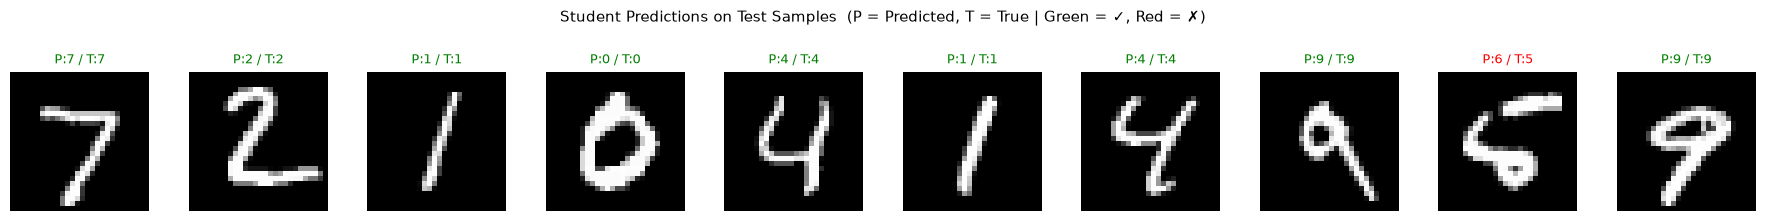

In [22]:
# Visualise first 10 test samples with predicted vs. true labels
n_samples = 10
fig, axes = plt.subplots(1, n_samples, figsize=(18, 2))

for i, ax in enumerate(axes):
    pred  = student_preds[i].item()
    truth = test_labels[i].item()
    color = 'green' if pred == truth else 'red'    # Green = correct, Red = wrong

    ax.imshow(test_images[i].squeeze(), cmap='gray')
    ax.set_title(f"P:{pred} / T:{truth}", color=color, fontsize=9)
    ax.axis('off')

fig.suptitle(
    "Student Predictions on Test Samples  (P = Predicted, T = True | Green = ✓, Red = ✗)",
    fontsize=11, y=1.08
)
plt.tight_layout()
plt.show()

---
## 8. Saving the Distilled Student Model

We save only the student's **state dictionary** (learned weights), not the full model object. This is the PyTorch best practice because:
- It is more portable — loading works as long as the `StudentMLP` class is defined.
- The file is smaller than pickling the entire model object.

To reload later:
```python
model = StudentMLP(hidden=128)
model.load_state_dict(torch.load('distilled_student.pth'))
model.eval()
```

In [23]:
save_path = "distilled_student.pth"

# Save only the state dict (recommended PyTorch practice)
torch.save(student.state_dict(), save_path)
print(f"Distilled student model saved to '{save_path}' ✅")

Distilled student model saved to 'distilled_student.pth' ✅


---
## 📊 Summary & Key Takeaways

| Aspect | Teacher | Distilled Student |
|---|---|---|
| Architecture | 784 → 512 → 256 → 10 | 784 → 128 → 10 |
| Parameters | ~530k | ~101k |
| Training signal | Hard labels only | Soft (teacher) + Hard labels |
| Test Accuracy | ~94.2% | ~94.2% |

### Key Takeaways

1. **Soft targets are information-rich.** The teacher's output for a "7" might assign small probability to "1" — capturing visual similarity. The student learns from this nuanced signal.
2. **Temperature controls knowledge transfer.** Higher temperature → softer distributions → more information about the relative likelihoods of wrong classes.
3. **The student matches the teacher despite being ~5× smaller.** This demonstrates that knowledge distillation is a powerful model compression strategy.
4. **Alpha balances old and new knowledge.** A high α (e.g., 0.7) trusts the teacher more; a low α relies more on hard ground-truth labels.

### Further Experiments to Try
- Increase `TEACHER_EPOCHS` to 5–10 for a stronger teacher.
- Vary `TEMPERATURE` (try 1, 4, 8) and observe the effect on student accuracy.
- Vary `ALPHA` (try 0.3, 0.5, 0.9).
- Replace MNIST with CIFAR-10 and use CNN architectures.